In [1]:
!pip install -q huggingface_hub nibabel pandas matplotlib

## 0. Setup & Auth

In [2]:
import os, glob, zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import userdata
from huggingface_hub import login, snapshot_download, hf_hub_download



In [3]:
login(token=userdata.get('HF_Token'))
REPO_ID = "Forithmus/MR-RATE"

## Data inventory

In [4]:
local_dir = snapshot_download(
    repo_id=REPO_ID,
    repo_type='dataset',
    allow_patterns=[
        'metadata/*.csv',
        'reports/*.csv',
        'pathology_labels/*.csv',
        'splits.csv',
    ]
)
print("downloaded in: ", local_dir)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 58 files:   0%|          | 0/58 [00:00<?, ?it/s]

downloaded in:  /root/.cache/huggingface/hub/datasets--Forithmus--MR-RATE/snapshots/f6e39794e7820c96c18465231a30da424e6d1c69


In [5]:
meta_files = sorted(glob.glob(f"{local_dir}/metadata/*_metadata.csv"))
report_files = sorted(glob.glob(f"{local_dir}/reports/*_reports.csv"))

meta = pd.concat(
    [pd.read_csv(f, dtype={"patient_uid": str, "study_uid": str}, low_memory=False) for f in meta_files],
    ignore_index=True,
)
reports = pd.concat(
    [pd.read_csv(f, dtype={"study_uid": str}, low_memory=False) for f in report_files],
    ignore_index=True,
)
pathology = pd.read_csv(f"{local_dir}/pathology_labels/mrrate_labels.csv",
                         dtype={"study_uid": str}, low_memory=False)
splits = pd.read_csv(f"{local_dir}/splits.csv",
                      dtype={"study_uid": str, "patient_uid": str}, low_memory=False)

print("metadata (series-level):", meta.shape)
print("reports (study-level)  :", reports.shape)
print("pathology (study-level):", pathology.shape)
print("splits (study-level)   :", splits.shape)
print("Định dạng batch_id:", splits["batch_id"].unique()[:5])

metadata (series-level): (705254, 316)
reports (study-level)  : (98200, 6)
pathology (study-level): (97896, 38)
splits (study-level)   : (98334, 4)
Định dạng batch_id: ['batch00' 'batch01' 'batch02' 'batch03' 'batch04']


## Join key sanity check

In [6]:
for name, df in [("reports", reports), ("pathology", pathology), ("splits", splits)]:
    match_rate = df["study_uid"].isin(meta["study_uid"]).mean()
    print(f"{name}: {match_rate:.1%} study_uid khớp với metadata")
    assert match_rate > 0.95, f"Tỉ lệ khớp thấp bất thường ở bảng {name} — kiểm tra lại key"

study_level = (
    meta.drop_duplicates("study_uid")[["study_uid", "patient_uid", "Patient'sAge", "Patient'sSex"]]
    .merge(reports, on="study_uid", how="left")
    .merge(pathology, on="study_uid", how="left")
    .merge(splits[["study_uid", "split", "batch_id"]], on="study_uid", how="left")
)
print("study_level:", study_level.shape)

reports: 100.0% study_uid khớp với metadata
pathology: 100.0% study_uid khớp với metadata
splits: 100.0% study_uid khớp với metadata
study_level: (98334, 48)


## Analyze patient/ study / series

In [7]:
print("Patients:", meta["patient_uid"].nunique())
print("Studies :", meta["study_uid"].nunique())
print("Series  :", len(meta))
print(meta.groupby("study_uid").size().describe())  # số series / study

Patients: 83425
Studies : 98334
Series  : 705254
count    98334.000000
mean         7.172026
std          3.018507
min          1.000000
25%          5.000000
50%          6.000000
75%          9.000000
max         83.000000
dtype: float64


## Acquisition metadata distribution

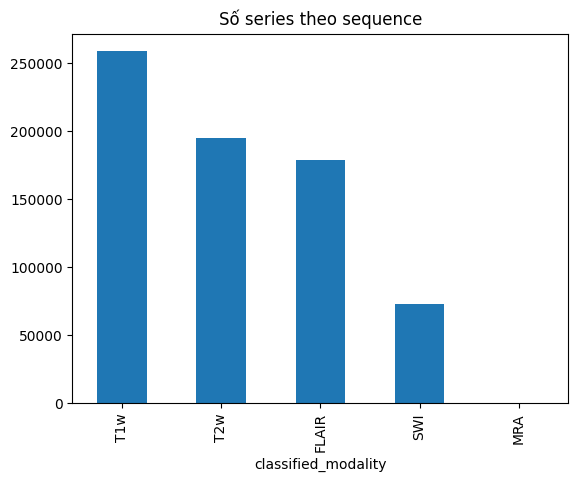

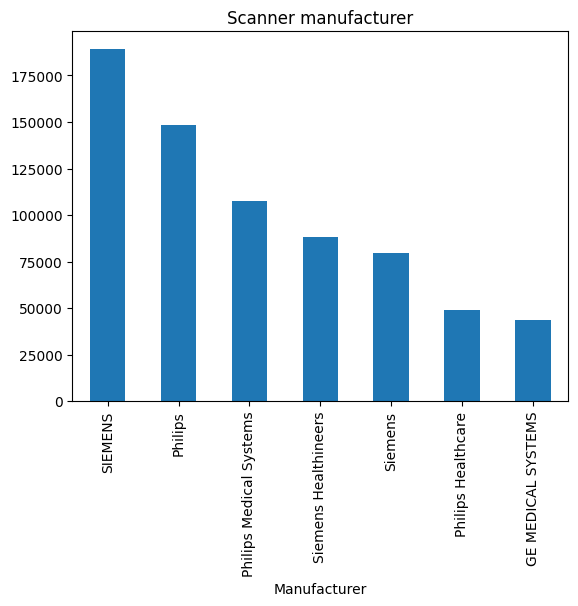

In [8]:
meta["classified_modality"].value_counts().plot(kind="bar", title="Số series theo sequence")
plt.show()

meta["Manufacturer"].value_counts().plot(kind="bar", title="Scanner manufacturer")
plt.show()



Missing sau khi parse: 0.0
count    98334.000000
mean        44.314988
std         17.633334
min         13.000000
25%         30.000000
50%         42.000000
75%         57.000000
max        140.000000
Name: age_years, dtype: float64


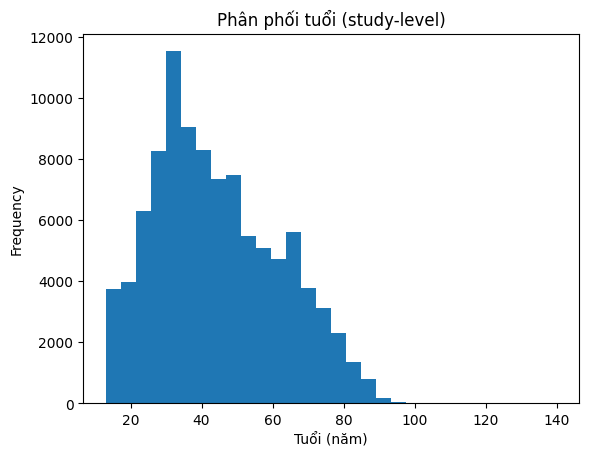

In [9]:
def parse_dicom_age(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if not val or not val[-1].isalpha():
        # đã là số thuần (vd "45" hoặc 45.0), thử ép kiểu trực tiếp
        try:
            return float(val)
        except ValueError:
            return np.nan
    num, unit = val[:-1], val[-1].upper()
    try:
        num = float(num)
    except ValueError:
        return np.nan
    return {
        "Y": num,
        "M": num / 12,
        "W": num / 52.1775,
        "D": num / 365.25,
    }.get(unit, np.nan)

study_level["age_years"] = study_level["Patient'sAge"].apply(parse_dicom_age)

print("Missing sau khi parse:", study_level["age_years"].isna().mean())
print(study_level["age_years"].describe())

study_level["age_years"].plot(kind="hist", bins=30, title="Phân phối tuổi (study-level)")
plt.xlabel("Tuổi (năm)")
plt.show()

**Interpretation note.** Parsed age reaches 140 years in the saved output. Treat extreme ages as a data-quality check before reporting age distributions or subgroup results.

## Pathology labels distribution

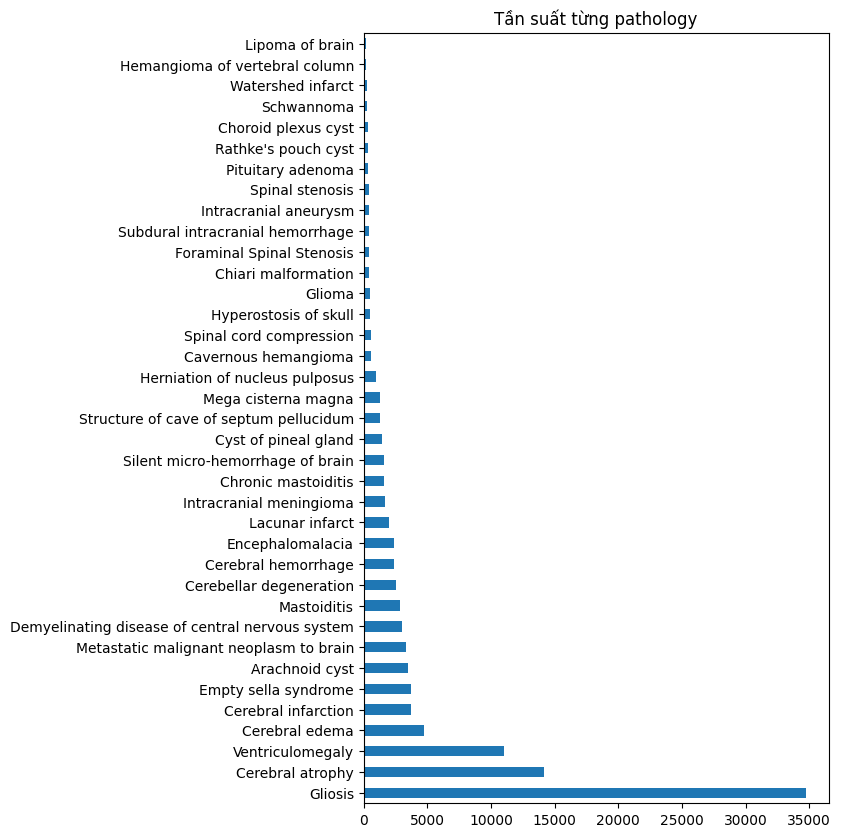

Số nhãn dương / study:
 count    97896.000000
mean         1.127942
std          1.411338
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         12.000000
dtype: float64


In [10]:
pathology_cols = [c for c in pathology.columns if c != "study_uid"]
label_counts = pathology[pathology_cols].sum().sort_values(ascending=False)
label_counts.plot(kind="barh", figsize=(6, 10), title="Tần suất từng pathology")
plt.show()

n_labels_per_study = pathology[pathology_cols].sum(axis=1)
print("Số nhãn dương / study:\n", n_labels_per_study.describe())

**Interpretation note.** These 37 study-level pathology labels are derived from report findings by the dataset's classification pipeline; they are not manually drawn lesion masks. The labels table has 97,896 rows versus 98,334 studies, so check label availability after joining. [Dataset card](https://huggingface.co/datasets/Forithmus/MR-RATE).

In [11]:
pathology_cols

['Cerebral infarction',
 'Cerebral hemorrhage',
 'Metastatic malignant neoplasm to brain',
 'Intracranial meningioma',
 'Demyelinating disease of central nervous system',
 'Herniation of nucleus pulposus',
 'Spinal cord compression',
 'Lacunar infarct',
 'Silent micro-hemorrhage of brain',
 'Cavernous hemangioma',
 'Subdural intracranial hemorrhage',
 'Gliosis',
 'Cerebral atrophy',
 'Encephalomalacia',
 'Arachnoid cyst',
 'Empty sella syndrome',
 'Intracranial aneurysm',
 'Chiari malformation',
 'Schwannoma',
 'Cyst of pineal gland',
 'Hemangioma of vertebral column',
 "Rathke's pouch cyst",
 'Cerebral edema',
 'Spinal stenosis',
 'Mastoiditis',
 'Chronic mastoiditis',
 'Ventriculomegaly',
 'Cerebellar degeneration',
 'Mega cisterna magna',
 'Structure of cave of septum pellucidum',
 'Hyperostosis of skull',
 'Watershed infarct',
 'Choroid plexus cyst',
 'Foraminal Spinal Stenosis',
 'Lipoma of brain',
 'Glioma',
 'Pituitary adenoma']

## Raidology report (text)

In [12]:
for col in ['clinical_information', 'technique', 'findings', 'impression']:
  lengths = reports[col].fillna("").str.split().apply(len)
  print(f"{col}: missing={reports[col].isna().mean():.1%}, "
          f"median words={lengths.median():.0f}, max words={lengths.max()}")

clinical_information: missing=52.0%, median words=0, max words=134
technique: missing=2.4%, median words=20, max words=261
findings: missing=0.3%, median words=143, max words=14262
impression: missing=8.8%, median words=17, max words=623


In [13]:
reports.sample(1, random_state=42)[['study_uid', 'findings', 'impression']].to_dict('records')

[{'study_uid': '6WQW5NTUDN',
  'findings': 'Scattered, multiple, chronic, nonspecific – gliotic lesions of millimetric size, hyperintense on T2-weighted and FLAIR, are observed in both centrum semiovale, periventricular deep white matter, and subcortical and deep white matter of both cerebral hemispheres.\nBilateral caudate nuclei, putamen, globus pallidus, and thalami appear normal. Corpus callosum is normal in thickness and intensity. Both internal and external capsules and claustrum are normal. Both hippocampi and substantia nigra have normal signal intensity and volume.\nPons, medulla oblongata, midbrain, cerebral and cerebellar peduncles are normal. Cerebellar hemispheres and vermis appear normal. No lesion was detected in the cerebellopontine angles. Cranial nerves 5, 7, and 8 are normal. Vestibule and cochlea appear normal. Meckel’s caves are observed normally.\nWidth of both lateral ventricles, 3rd, and 4th ventricles is normal. Quadrigeminal, ambient, suprasellar, prepontine, 

## Plit & lekage check based patient_uid

In [14]:
patient_split = study_level.groupby('patient_uid')['split'].nunique()
leaking = patient_split[patient_split > 1]
print(f'num of patient is existing more than one split: {len(leaking)}')

num of patient is existing more than one split: 0


In [15]:
assert len(leaking) == 0
print(study_level['split'].value_counts())

split
train    88985
test      5568
val       3781
Name: count, dtype: int64


## Image checking
download some sample to checking

In [16]:
N = 20

sample_studies = study_level.dropna(subset=['batch_id']).sample(N, random_state=42)


In [17]:
sample_paths = []
for _, row in sample_studies.iterrows():
  batch_id = row['batch_id']
  zip_path = hf_hub_download(
      repo_id=REPO_ID,
      repo_type='dataset',
      filename=f'mri/{batch_id}/{row['study_uid']}.zip',
  )
  sample_paths.append((row["study_uid"], zip_path))

In [18]:
print(sample_paths)

[('LWRANBTOB3', '/root/.cache/huggingface/hub/datasets--Forithmus--MR-RATE/snapshots/f6e39794e7820c96c18465231a30da424e6d1c69/mri/batch12/LWRANBTOB3.zip'), ('5DF6PAT6D5', '/root/.cache/huggingface/hub/datasets--Forithmus--MR-RATE/snapshots/f6e39794e7820c96c18465231a30da424e6d1c69/mri/batch23/5DF6PAT6D5.zip'), ('DB5JJYXKYA', '/root/.cache/huggingface/hub/datasets--Forithmus--MR-RATE/snapshots/f6e39794e7820c96c18465231a30da424e6d1c69/mri/batch23/DB5JJYXKYA.zip'), ('OMJGZSCSFQ', '/root/.cache/huggingface/hub/datasets--Forithmus--MR-RATE/snapshots/f6e39794e7820c96c18465231a30da424e6d1c69/mri/batch21/OMJGZSCSFQ.zip'), ('RINI6MU636', '/root/.cache/huggingface/hub/datasets--Forithmus--MR-RATE/snapshots/f6e39794e7820c96c18465231a30da424e6d1c69/mri/batch19/RINI6MU636.zip'), ('MXLEBATV72', '/root/.cache/huggingface/hub/datasets--Forithmus--MR-RATE/snapshots/f6e39794e7820c96c18465231a30da424e6d1c69/mri/batch12/MXLEBATV72.zip'), ('XWC5DLHM2F', '/root/.cache/huggingface/hub/datasets--Forithmus--MR-

## unzip and visualize middle

Tìm được 20 ảnh để vẽ (từ 20 study đã giải nén).


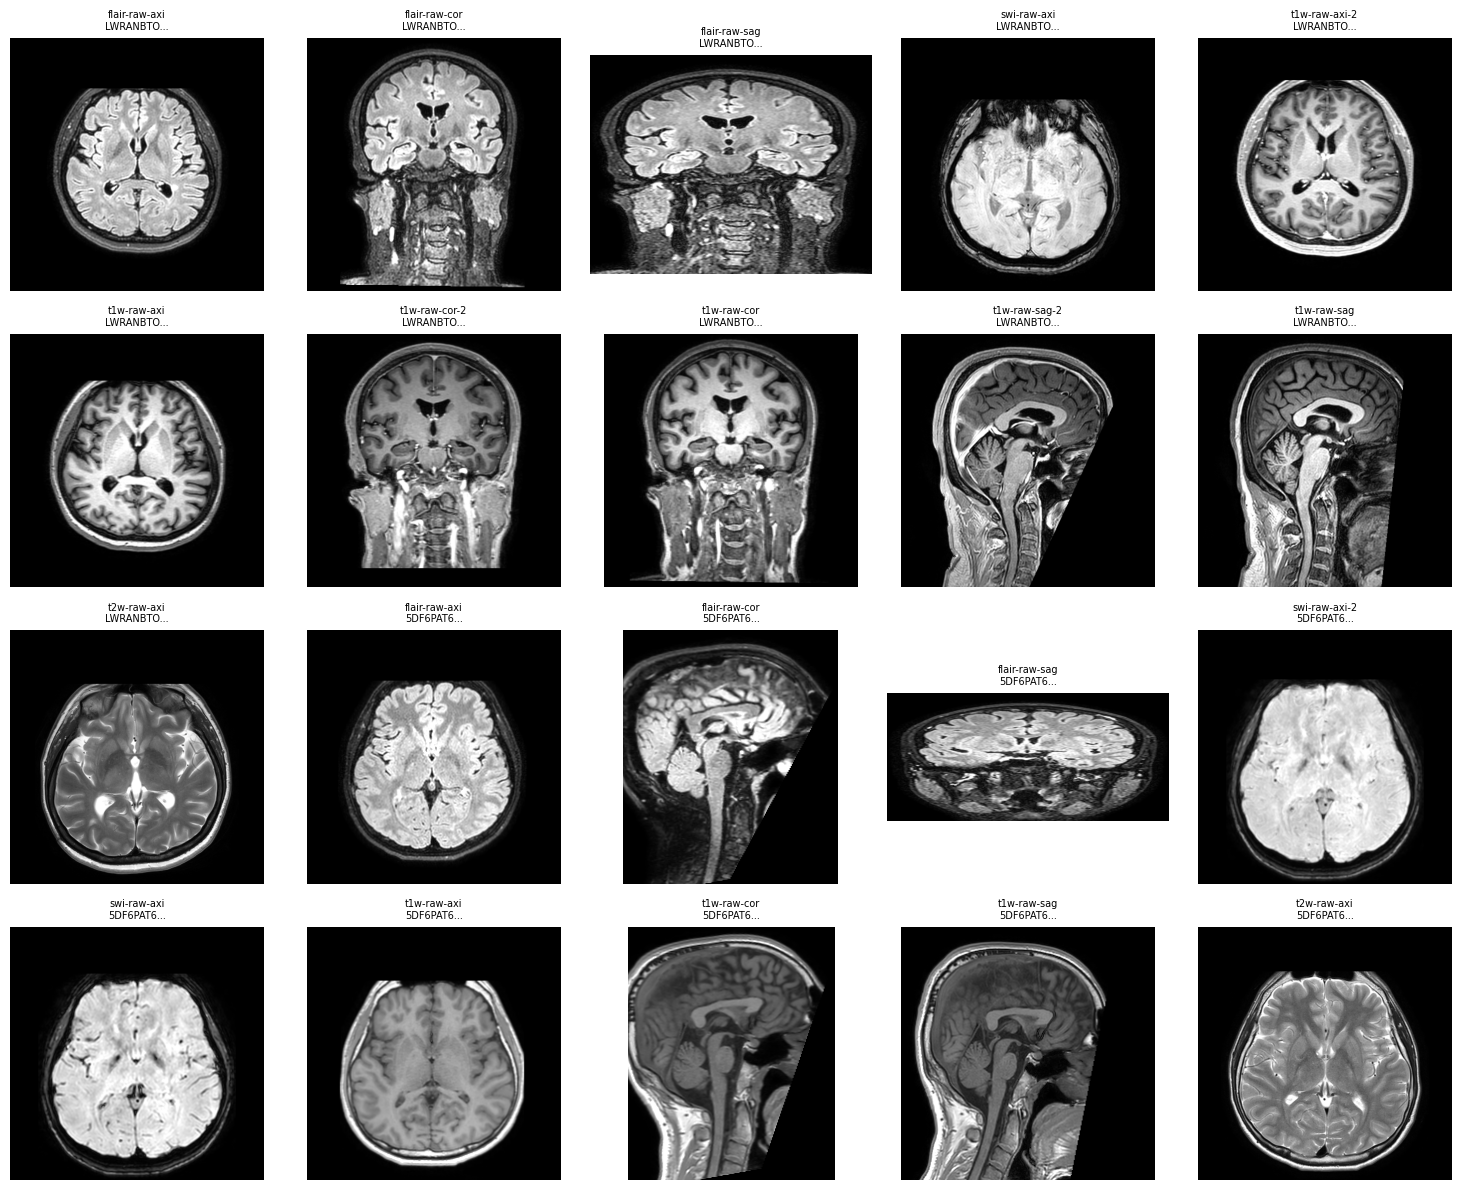

In [21]:
import nibabel as nib

extract_dir = "/content/mr_rate_samples"
os.makedirs(extract_dir, exist_ok=True)

cols, rows = 5, 4
max_n = cols * rows

# --- Gom tối đa max_n ảnh từ các study đã giải nén (mọi series, không chỉ center modality) ---
slice_entries = []
for study_uid, _ in sample_paths:
    img_dir = f"{extract_dir}/{study_uid}/img"
    if not os.path.isdir(img_dir):
        continue
    for fname in sorted(os.listdir(img_dir)):
        if not fname.endswith(".nii.gz"):
            continue
        series_id = fname.replace(f"{study_uid}_", "").replace(".nii.gz", "")
        slice_entries.append((study_uid, series_id, os.path.join(img_dir, fname)))
        if len(slice_entries) >= max_n:
            break
    if len(slice_entries) >= max_n:
        break

print(f"Tìm được {len(slice_entries)} ảnh để vẽ (từ {len(sample_paths)} study đã giải nén).")


def get_display_slice(arr, spacing):
    """Chọn trục through-plane = trục có spacing lớn nhất (lát dày nhất),
    cắt lát giữa, và trả về aspect ratio đúng theo spacing thật của 2 trục còn lại."""
    through_axis = int(np.argmax(spacing))  # trục "dày" nhất = trục cắt lát trong acquisition 2D
    mid = arr.shape[through_axis] // 2
    sl = np.take(arr, mid, axis=through_axis)

    remaining_axes = [ax for ax in range(3) if ax != through_axis]
    row_spacing = spacing[remaining_axes[0]]
    col_spacing = spacing[remaining_axes[1]]
    aspect = row_spacing / col_spacing  # tỉ lệ vật lý thật giữa 2 trục hiển thị
    return sl, aspect


# --- Vẽ lưới cols x rows ---
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.array(axes).reshape(-1)

for ax, (study_uid, series_id, nii_path) in zip(axes, slice_entries):
    img = nib.load(nii_path)
    arr = img.get_fdata()
    spacing = img.header.get_zooms()[:3]

    sl, aspect = get_display_slice(arr, spacing)
    vmin, vmax = np.percentile(sl, [1, 99])
    ax.imshow(sl.T, cmap="gray", vmin=vmin, vmax=vmax, origin="lower", aspect=aspect)
    ax.set_title(f"{series_id}\n{study_uid[:8]}...", fontsize=7)
    ax.axis("off")

for ax in axes[len(slice_entries):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

if len(slice_entries) < max_n:
    print(f"Đã vẽ {len(slice_entries)}/{max_n} ô — nếu thiếu, tăng N ở Section 8 để có nhiều study/series hơn.")

## data quality scan

In [22]:
bad_files = []
for study_uid, _ in sample_paths:
    img_dir = f"{extract_dir}/{study_uid}/img"
    for fname in os.listdir(img_dir):
        try:
            nib.load(os.path.join(img_dir, fname)).header
        except Exception as e:
            bad_files.append((fname, str(e)))

print("File lỗi:", bad_files if bad_files else "Không có")

File lỗi: Không có
